In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Milestone 1 - NLP Foundation & Semantic Similarity

# Question 1

## Frequency Distribution of Correct Answers

Calculate the frequency distribution of the correct answers (A, B, C, D, E) in `train.csv`.

**Answer:** 814

In [2]:
df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

In [3]:
counts = df['answer'].value_counts()

most_freq = counts.iloc[0]
least_freq = counts.iloc[-1]

print(f"Most frequent count: {most_freq}")
print(f"Least frequent count: {least_freq}")
print(f"Sum: {most_freq + least_freq}")

Most frequent count: 490
Least frequent count: 324
Sum: 814


# Question 2

## Vocabulary Size of Cleaned Prompts

After converting the `prompt` column to lowercase and removing all standard punctuation characters (`string.punctuation`), split the text by whitespace.

Determine the total number of unique words across the entire cleaned prompt column.

**Answer:** 859

In [4]:
import string

def clean_text(text):
    text = str(text).lower()
    # Remove punctuation using string.punctuation
    for p in string.punctuation:
        text = text.replace(p, '')
    # Split by whitespace
    return set(text.split())

global_vocab = set()
for prompt in df['prompt']:
    global_vocab.update(clean_text(prompt))

print(f"Total unique words: {len(global_vocab)}")

Total unique words: 859


# Question 3

## Stop Word Removal

Using the cleaned prompt from Row ID 1, remove standard English stop words using:

`sklearn.feature_extraction.text.ENGLISH_STOP_WORDS`

Determine the number of words remaining.

**Answer:** 13

In [5]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Clean the first row's prompt
row_1_words = clean_text(df.iloc[0]['prompt'])

# Filter out stop words
filtered_words = [w for w in row_1_words if w not in ENGLISH_STOP_WORDS]

print(f"Words left after filtering: {len(filtered_words)}")

Words left after filtering: 13


# Question 4

## TF-IDF Vocabulary Size

Fit a default TF-IDF vectorizer:

`TfidfVectorizer(stop_words='english')`

on the combined text of all prompts and options in `train.csv`.

Determine the total number of generated feature columns.

**Answer:** 2762

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine prompts and all options into one single text per row
# Using fillna('') to prevent errors from empty cells
combined_text = (df['prompt'].fillna('') + ' ' + 
                 df['A'].fillna('') + ' ' + 
                 df['B'].fillna('') + ' ' + 
                 df['C'].fillna('') + ' ' + 
                 df['D'].fillna('') + ' ' + 
                 df['E'].fillna(''))

vectorizer = TfidfVectorizer(stop_words='english')
vectorizer.fit(combined_text)

print(f"Total feature columns: {len(vectorizer.get_feature_names_out())}")

Total feature columns: 2762


# Question 5

## Cosine Similarity for Row ID 1

Using the TF-IDF vectorizer from Question 4, calculate the cosine similarity between the prompt and Option A for Row ID 1.

Round the result to 4 decimal places.

**Answer:** 0.2720

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Transform the specific strings for Row 1
prompt_vec = vectorizer.transform([str(df.iloc[0]['prompt'])])
opt_a_vec = vectorizer.transform([str(df.iloc[0]['A'])])

# Calculate similarity
sim_score = cosine_similarity(prompt_vec, opt_a_vec)[0][0]

print(f"Similarity Score: {round(sim_score, 4)}")

Similarity Score: 0.272


# Question 6

## Highest Similarity Accuracy

For every row in `train.csv`:

1. Calculate cosine similarity between the prompt and each option (A-E).
2. Select the option with the highest similarity.
3. Compare it with the correct answer.

Determine the percentage of correct predictions.

**Answer:** 13.55%

In [8]:
correct_matches = 0
options = ['A', 'B', 'C', 'D', 'E']

for idx, row in df.iterrows():
    prompt_vec = vectorizer.transform([str(row['prompt'])])
    
    # Calculate similarities for all 5 options
    sims = [cosine_similarity(prompt_vec, vectorizer.transform([str(row[opt])]))[0][0] for opt in options]
    
    # Find the option with the highest score
    best_option = options[sims.index(max(sims))]
    
    if best_option == row['answer']:
        correct_matches += 1

percentage = (correct_matches / len(df)) * 100
print(f"Accuracy percentage: {round(percentage, 2)}%")

Accuracy percentage: 13.55%


# Question 7

## MAP@3 Calculation (Case 1)

Ground Truth: C

Predictions:
C A B

**MAP@3 Score:** 1.0

# Question 8

## MAP@3 Calculation (Case 2)

Ground Truth: B

Predictions:
D B E

**MAP@3 Score:** 0.5

# Question 9

## Majority Class Baseline

Find the most frequent correct answer in the training set.

For every row:

- 1st prediction = Most frequent answer
- 2nd prediction = Second most frequent answer
- 3rd prediction = Third most frequent answer

Calculate the overall MAP@3 score.

**Answer:** 0.42125

In [9]:
import numpy as np

def apk(actual, predicted, k=3):
    """Computes Average Precision at K for a single query."""
    if len(predicted) > k:
        predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)

    if not actual:
        return 0.0
    return score / min(len(actual), k)

def mapk(actual_list, predicted_list, k=3):
    """
    Computes Mean Average Precision at K for multiple queries.
    actual_list: List of lists containing the true answers (e.g., [['A'], ['C']])
    predicted_list: List of lists containing the top 3 predictions (e.g., [['A', 'B', 'C'], ['B', 'A', 'D']])
    """
    return np.mean([apk(a, p, k) for a, p in zip(actual_list, predicted_list)])

# Example Usage:
# actual_answers = [['A'], ['C'], ['B']]
# model_predictions = [['A', 'B', 'C'], ['A', 'C', 'B'], ['D', 'E', 'A']] # The last one missed the target
# map3_score = mapk(actual_answers, model_predictions, k=3)
# print(f"mAP@3 Score: {map3_score}")

In [10]:
# Get the top 3 most frequent answers overall
top_3_classes = df['answer'].value_counts().index[:3].tolist()

# The ground truth answers
actual_answers = [[ans] for ans in df['answer']]

# The static prediction for every single row
majority_predictions = [top_3_classes for _ in range(len(df))]

majority_map3 = mapk(actual_answers, majority_predictions, k=3)
print(f"Majority Class Baseline MAP@3: {majority_map3}")

Majority Class Baseline MAP@3: 0.42125


# Question 10

## TF-IDF Similarity Pipeline

For each row:

1. Compute TF-IDF cosine similarity between the prompt and all five options.
2. Rank options from highest to lowest similarity.
3. Select the top 3 predictions.
4. Calculate MAP@3.

Determine the average MAP@3 score across the entire training dataset.

**Answer:** 0.2961666666666667

In [11]:
tfidf_predictions = []

for idx, row in df.iterrows():
    prompt_vec = vectorizer.transform([str(row['prompt'])])
    
    # Store options and their scores in a dictionary
    sim_dict = {opt: cosine_similarity(prompt_vec, vectorizer.transform([str(row[opt])]))[0][0] for opt in options}
    
    # Sort dictionary by similarity score in descending order
    sorted_options = sorted(sim_dict.items(), key=lambda item: item[1], reverse=True)
    
    # Extract the top 3 option letters
    top_3_preds = [opt[0] for opt in sorted_options[:3]]
    tfidf_predictions.append(top_3_preds)

tfidf_map3 = mapk(actual_answers, tfidf_predictions, k=3)
print(f"TF-IDF Pipeline MAP@3: {tfidf_map3}")

TF-IDF Pipeline MAP@3: 0.2961666666666667


# **MY CODE**

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded")

Libraries loaded


In [13]:
# Load train and test
train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (2000, 8)
Test shape : (500, 7)


In [14]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [15]:
train.describe()

,id
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [17]:
print("\nNull values:\n", train.isnull().sum())
print("\nDuplicate rows:", train.duplicated().sum())


Null values:
 id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Duplicate rows: 0


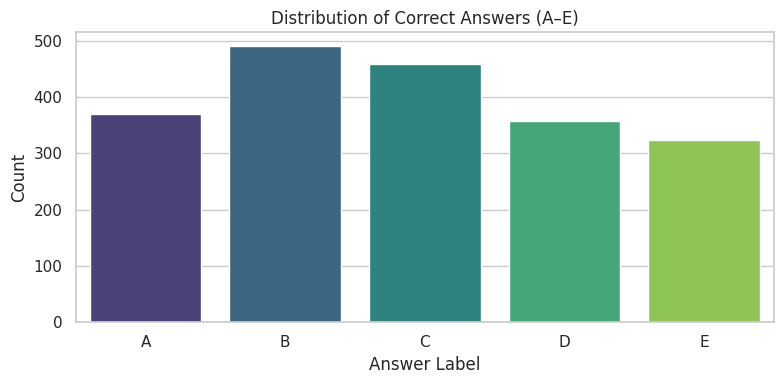

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

Balance check (%):
 answer
A    18.45
B    24.50
C    22.95
D    17.90
E    16.20
Name: count, dtype: float64


In [18]:
# Distribution of correct answers
answer_counts = train['answer'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=answer_counts.index, y=answer_counts.values, palette='viridis')
plt.title('Distribution of Correct Answers (A–E)')
plt.xlabel('Answer Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(answer_counts)
print("\nBalance check (%):\n", (answer_counts / len(train) * 100).round(2))

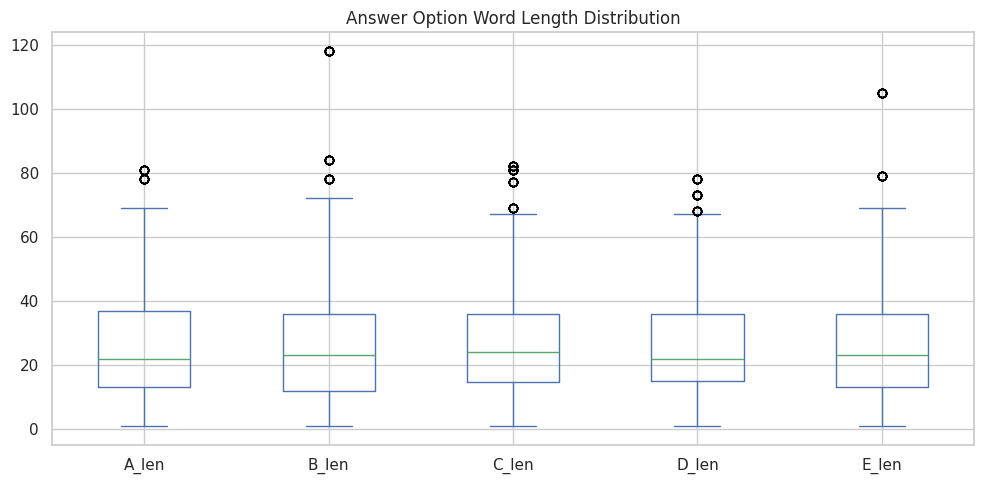

In [19]:
for opt in ['A', 'B', 'C', 'D', 'E']:
    train[f'{opt}_len'] = train[opt].apply(lambda x: len(str(x).split()))

opt_len_cols = [f'{opt}_len' for opt in ['A', 'B', 'C', 'D', 'E']]
train[opt_len_cols].plot(kind='box', figsize=(10, 5))
plt.title('Answer Option Word Length Distribution')
plt.tight_layout()
plt.show()

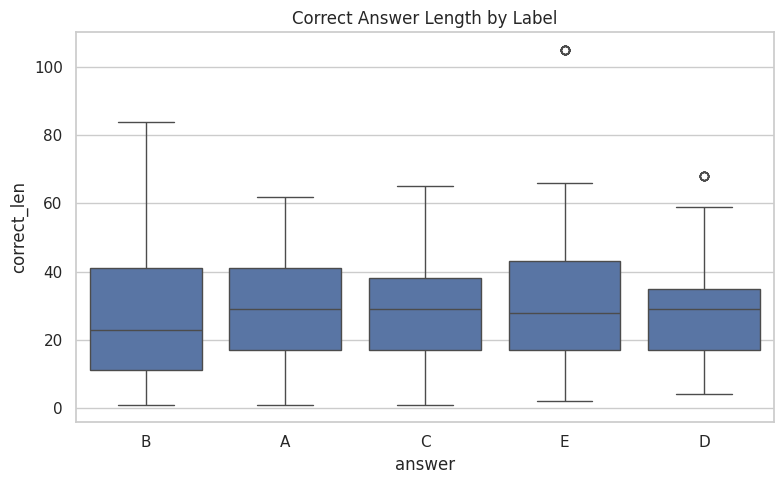

In [20]:
def get_correct_option_length(row):
    col = row['answer']   # column is just 'A', 'B', etc.
    return len(str(row[col]).split())

train['correct_len'] = train.apply(get_correct_option_length, axis=1)

plt.figure(figsize=(8, 5))
sns.boxplot(x='answer', y='correct_len', data=train)
plt.title('Correct Answer Length by Label')
plt.tight_layout()
plt.show()

In [21]:
# Compare mean length of correct vs all options
for opt in ['A', 'B', 'C', 'D', 'E']:
    train[f'{opt}_len'] = train[opt].apply(lambda x: len(str(x).split()))

correct_lengths = train.apply(
    lambda row: row[f"{row['answer']}_len"], axis=1
)
all_lengths = train[opt_len_cols].values.flatten()

print(f"Mean length of CORRECT options: {correct_lengths.mean():.2f}")
print(f"Mean length of ALL options:     {pd.Series(all_lengths).mean():.2f}")

Mean length of CORRECT options: 28.66
Mean length of ALL options:     26.28


count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: q_len, dtype: float64


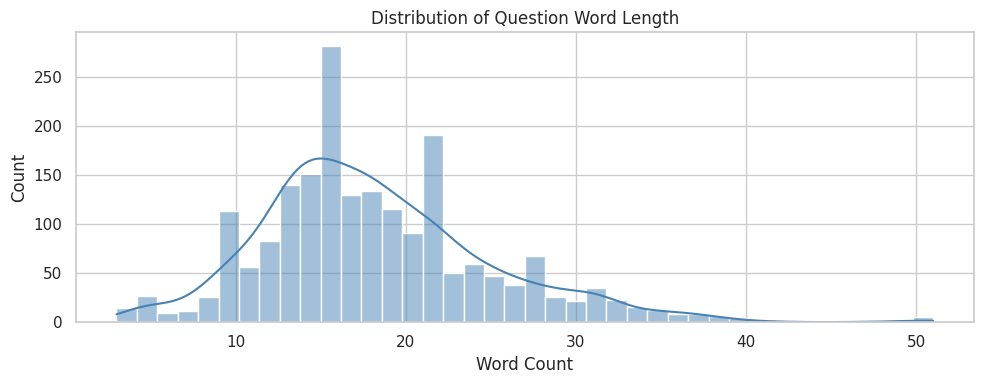

In [22]:
# Question length analysis
train['q_len'] = train['prompt'].apply(lambda x: len(x.split()))

print(train['q_len'].describe())

plt.figure(figsize=(10, 4))
sns.histplot(train['q_len'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Question Word Length')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()

In [23]:
# Most common answer label
most_common = answer_counts.idxmax()
remaining   = [x for x in ['A','B','C','D','E'] if x != most_common][:2]
baseline_pred = f"{most_common} {remaining[0]} {remaining[1]}"

submission = pd.DataFrame({
    'ID': range(1, len(test) + 1),  # adjust column name
    'Prediction': baseline_pred
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f"\nBaseline prediction: {baseline_pred}")

   ID Prediction
0   1      B A C
1   2      B A C
2   3      B A C
3   4      B A C
4   5      B A C

Baseline prediction: B A C
